# IQR-Bereinigung

Dieses Notebook untersucht die Ausreißerbehandlung für den California-Housing-Datensatz und vergleicht verschiedene Ansätze für die Datenvorbereitung und Modellierung.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow.keras as keras
from sklearn.datasets import fetch_california_housing

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

2026-04-07 18:03:08.121621: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-07 18:03:08.122189: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 18:03:08.167397: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 18:03:09.355953: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

# 1. Datenvorbereitung und Bereinigung

In diesem Abschnitt werden die Daten zunächst bereinigt, transformiert und für spätere Modellierungsversuche vorbereitet.

- Die maximalen Werte bei MedHouseVal, HouseAge und MedInc werden entfernt.
- Die IQR-Methode wird verwendet, um Ausreißer zu identifizieren und zu entfernen.
- Schief verteilte Merkmale werden log-transformiert.
- Zusätzliche Features wie BedrmsPerRoom und Entfernungen zu den Städten LA, SF und SJ werden erzeugt.

In [ ]:
SEED = 42
SF_COORDS = (37.7749, -122.4194)
LA_COORDS = (34.0522, -118.2437)
SJ_COORDS = (37.3362, -121.8833)


def prepare_data(use_winsorizing=False):
    data = fetch_california_housing()
    df = pd.DataFrame(data=data.data, columns=data.feature_names)
    df[data.target_names[0]] = data.target

    mask_cutoff = (
        (df["MedHouseVal"] < df["MedHouseVal"].max())
        & (df["HouseAge"] < df["HouseAge"].max())
        & (df["MedInc"] < df["MedInc"].max())
    )
    df_clean = df[mask_cutoff].copy()

    if use_winsorizing:
        clip_columns = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
        for column in clip_columns:
            lower_bound = df_clean[column].quantile(0.01)
            upper_bound = df_clean[column].quantile(0.99)
            df_clean[column] = df_clean[column].clip(lower=lower_bound, upper=upper_bound)
    else:
        iqr_columns = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
        q1 = df_clean[iqr_columns].quantile(0.25)
        q3 = df_clean[iqr_columns].quantile(0.75)
        iqr = q3 - q1
        iqr_mask = (
            (df_clean[iqr_columns] >= q1 - 1.5 * iqr)
            & (df_clean[iqr_columns] <= q3 + 1.5 * iqr)
        ).all(axis=1)
        df_clean = df_clean[iqr_mask]

    df_clean["BedrmsPerRoom"] = df_clean["AveBedrms"] / df_clean["AveRooms"]

    df_clean["MedInc"] = np.log1p(df_clean["MedInc"])
    df_clean["Population"] = np.log1p(df_clean["Population"])
    df_clean["AveBedrms"] = np.log1p(df_clean["AveBedrms"])

    df_clean["Dist_to_SF"] = np.sqrt(
        (df_clean["Latitude"] - SF_COORDS[0]) ** 2
        + (df_clean["Longitude"] - SF_COORDS[1]) ** 2
    )
    df_clean["Dist_to_LA"] = np.sqrt(
        (df_clean["Latitude"] - LA_COORDS[0]) ** 2
        + (df_clean["Longitude"] - LA_COORDS[1]) ** 2
    )
    df_clean["Dist_to_SJ"] = np.sqrt(
        (df_clean["Latitude"] - SJ_COORDS[0]) ** 2
        + (df_clean["Longitude"] - SJ_COORDS[1]) ** 2
    )

    features = df_clean.drop("MedHouseVal", axis=1)
    target = df_clean["MedHouseVal"].copy()

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
        features, target, test_size=0.2, random_state=SEED
    )

    scaler = sklearn.preprocessing.StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return df_clean, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled


df_clean, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled = prepare_data(
    use_winsorizing=False
)

df_clean.describe()
print(f"Originaler Datensatz: {df_clean.shape}")

originaler Datensatzg: (20640, 9)
bereinigter Datensatz (15686, 13)


# 2. Bisher bestes Modell

Das folgende Modell wird auf den bereinigten Daten ohne zusätzliche Winsorizing-Strategie trainiert.

In [ ]:

def build_model(input_dim, layer_sizes, dropout_rate=0.2):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])

    for units in layer_sizes:
        model.add(keras.layers.Dense(units, activation="relu"))
        model.add(keras.layers.BatchNormalization())
        if dropout_rate is not None:
            model.add(keras.layers.Dropout(dropout_rate))

    model.add(keras.layers.Dense(1, activation="linear"))
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


model = build_model(X_train.shape[1], [128, 64, 32])
model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ],
    verbose=0,
)

test_scores = model.evaluate(X_test, y_test, verbose=0)
print(f"MSE: {test_scores[0]:.2f}")
print(f"MAE: {test_scores[1]:.2f}")

Epoch 1/150


2026-03-31 15:10:43.523866: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6760 - mae: 0.6070 - val_loss: 15.4273 - val_mae: 3.8590 - learning_rate: 0.0010
Epoch 2/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - loss: 0.3803 - mae: 0.4555 - val_loss: 8.4403 - val_mae: 2.7940 - learning_rate: 0.0010
Epoch 3/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - loss: 0.3328 - mae: 0.4235 - val_loss: 13.9836 - val_mae: 3.6074 - learning_rate: 0.0010
Epoch 4/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - loss: 0.3187 - mae: 0.4140 - val_loss: 21.7174 - val_mae: 4.5826 - learning_rate: 0.0010
Epoch 5/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - loss: 0.3071 - mae: 0.4024 - val_loss: 4.2057 - val_mae: 1.9164 - learning_rate: 0.0010
Epoch 6/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - loss: 0.3074 - mae: 0.4038 - val_loss: 0.7837 - val_mae: 0.7491 - learning_rate: 0.0010
Epoch 7/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.2995 - mae: 0.3978 - val_loss: 1.8068 - val_mae: 1.2148 - learning_rate: 0.0

# 3. Die IQR-Methode verbessern

Die IQR-Methode entfernt einen großen Anteil der Datenpunkte. Als Alternative wird hier das Winsorizing eingesetzt, bei dem Ausreißer auf definierte Grenzen gekappt werden.

In [ ]:
_, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled = prepare_data(
    use_winsorizing=True
)
print(f"Neue Datensatzgröße: {df_clean.shape}")

# 4. Overfitting vermeiden

Um Überanpassung zu reduzieren, werden nach den größeren Dense-Layern Batch-Normalization und Dropout ergänzt.

In [5]:
model = build_model(X_train_scaled.shape[1], [128, 64, 32], dropout_rate=0.2)
model.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ],
    verbose=0,
)

test_scores = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"MSE: {test_scores[0]:.2f}")
print(f"MAE: {test_scores[1]:.2f}")

Epoch 1/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.9296 - mae: 1.3803 - val_loss: 0.9957 - val_mae: 0.7733 - learning_rate: 0.0010
Epoch 2/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0147 - mae: 0.7696 - val_loss: 0.3519 - val_mae: 0.4204 - learning_rate: 0.0010
Epoch 3/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7129 - mae: 0.6472 - val_loss: 0.2907 - val_mae: 0.3839 - learning_rate: 0.0010
Epoch 4/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5906 - mae: 0.5847 - val_loss: 0.2678 - val_mae: 0.3690 - learning_rate: 0.0010
Epoch 5/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5139 - mae: 0.5379 - val_loss: 0.2642 - val_mae: 0.3636 - learning_rate: 0.0010
Epoch 6/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4630 - mae: 0.5099 - val_loss: 0.2600 - val_mae: 0.3581 - learning_rate: 0.0010
Epoch 7/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4207 - mae: 0.4854 - val_loss: 0.2460 - val_mae: 0.3519 - learning_rate: 0.0010

Der Score ist leicht besser geworden.

# 5. Boxplot zum Vergleich von Trimming und Winsorizing

/tmp/ipykernel_565937/28581135.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Methode', y='Wert', palette='Set2')


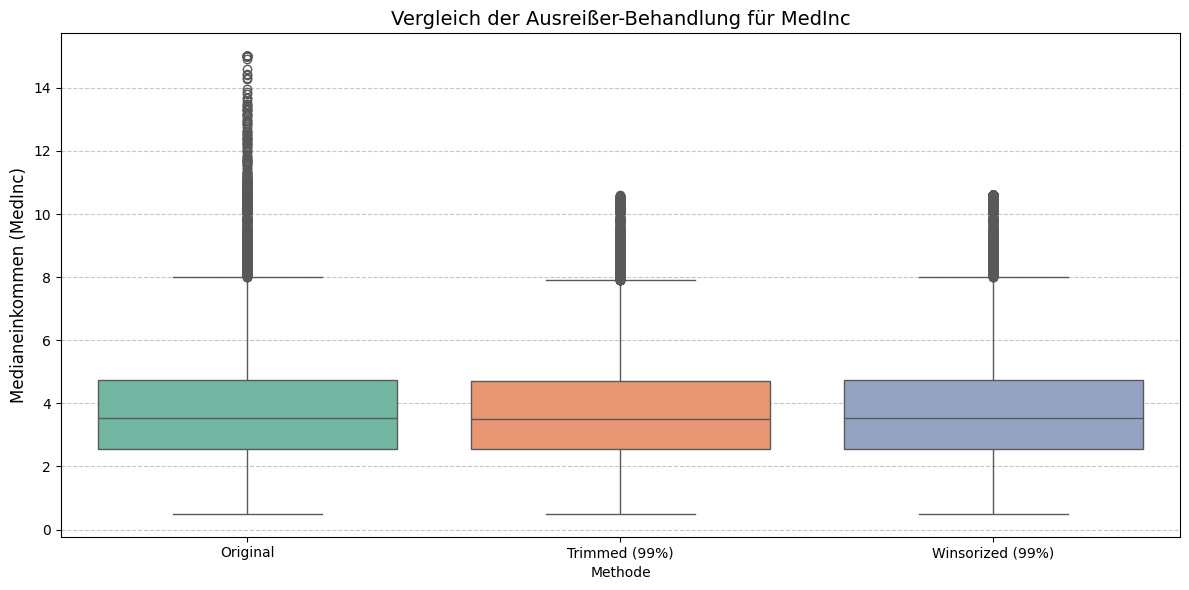

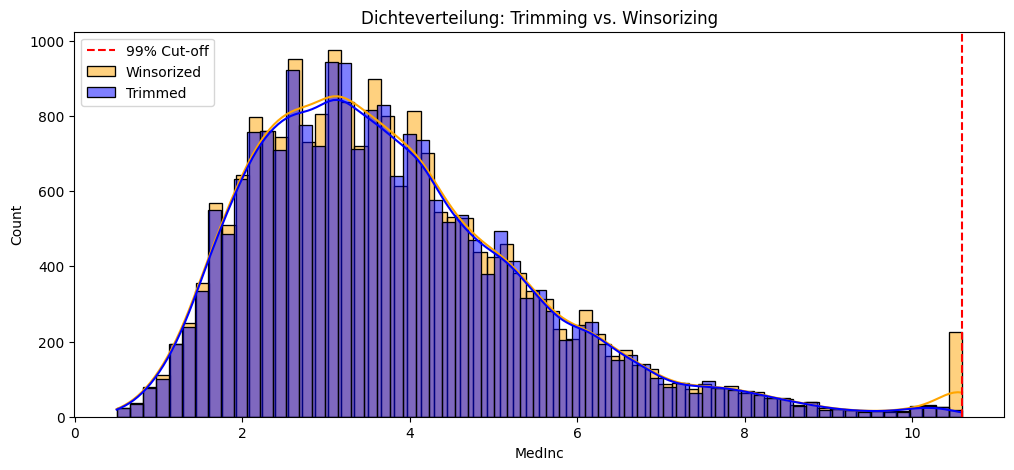

In [7]:
data = fetch_california_housing()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df[data.target_names[0]] = data.target

feature = "MedInc"
upper_limit = df[feature].quantile(0.99)

df_trimmed = df[df[feature] <= upper_limit].copy()
df_winsorized = df.copy()
df_winsorized[feature] = df_winsorized[feature].clip(upper=upper_limit)

plt.figure(figsize=(12, 6))
data_to_plot = pd.DataFrame(
    {
        "Original": df[feature],
        "Trimmed (99%)": pd.Series(df_trimmed[feature]),
        "Winsorized (99%)": df_winsorized[feature],
    }
)
df_melted = data_to_plot.melt(var_name="Methode", value_name="Wert")

sns.boxplot(data=df_melted, x="Methode", y="Wert", palette="Set2")
plt.title(f"Vergleich der Ausreißer-Behandlung für {feature}", fontsize=14)
plt.ylabel("Medianeinkommen (MedInc)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("boxplot_medinc.pdf", format="pdf")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df_winsorized[feature], kde=True, color="orange", label="Winsorized")
sns.histplot(df_trimmed[feature], kde=True, color="blue", label="Trimmed", alpha=0.5)
plt.axvline(upper_limit, color="red", linestyle="--", label="99% Cut-off")
plt.title("Dichteverteilung: Trimming vs. Winsorizing")
plt.legend()
plt.savefig("dichteverteilung_medinc.pdf", format="pdf")
plt.show()

In [ ]:
# Abschlusszelle zur Ergänzung der Analyse.